In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow_datasets as tfds

C:\Users\JimmyWu\.conda\envs\fds_cw3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## TensorFlow augmentation 7 methods 

In [2]:
SEED = 42
BATCH_SIZE = 64
EPOCHS = 20

tf.random.set_seed(SEED)
np.random.seed(SEED)


# Model
def build_cnn(input_shape, num_classes, onehot=False):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ])

    loss = "categorical_crossentropy" if onehot else "sparse_categorical_crossentropy"
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=loss,
        metrics=["accuracy"]
    )
    return model


# Common augmentation layers (create once)
rot = tf.keras.layers.RandomRotation(0.08)
trans = tf.keras.layers.RandomTranslation(0.08, 0.08)
zm = tf.keras.layers.RandomZoom(0.10)
con = tf.keras.layers.RandomContrast(0.10)


# 8 methods (0~7)
def method0(x, y):
    return x, y

def method1(x, y):
    x = rot(x, training=True)
    return x, y

def method2(x, y):
    x = trans(x, training=True)
    return x, y

def method3(x, y):
    x = zm(x, training=True)
    return x, y

def method4(x, y, is_rgb):
    x = rot(x, training=True)
    x = trans(x, training=True)
    x = zm(x, training=True)
    if is_rgb:
        x = con(x, training=True)
    return x, y

# Method 5: MixUp (one-hot y)
def method5(x, y, num_classes):
    y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)

    batch_size = tf.shape(x)[0]
    alpha = 0.2

    a = tf.random.gamma([batch_size], alpha)
    b = tf.random.gamma([batch_size], alpha)
    lam = a / (a + b + 1e-8)

    lam_x = tf.reshape(lam, [batch_size, 1, 1, 1])
    lam_y = tf.reshape(lam, [batch_size, 1])

    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    x = x * lam_x + x2 * (1.0 - lam_x)
    y = y * lam_y + y2 * (1.0 - lam_y)
    return x, y

# Method 6: CutMix (one-hot y, simple batch-wise)
def method6(x, y, num_classes):
    y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)

    batch_size = tf.shape(x)[0]
    height = tf.shape(x)[1]
    width = tf.shape(x)[2]
    channels = tf.shape(x)[3]

    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    alpha = 1.0
    a = tf.random.gamma([], alpha)
    b = tf.random.gamma([], alpha)
    lam = a / (a + b + 1e-8)

    cut_ratio = tf.sqrt(1.0 - lam)
    cut_w = tf.cast(tf.cast(width, tf.float32) * cut_ratio, tf.int32)
    cut_h = tf.cast(tf.cast(height, tf.float32) * cut_ratio, tf.int32)

    cx = tf.random.uniform([], 0, width, dtype=tf.int32)
    cy = tf.random.uniform([], 0, height, dtype=tf.int32)

    x1 = tf.clip_by_value(cx - cut_w // 2, 0, width)
    x2b = tf.clip_by_value(cx + cut_w // 2, 0, width)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, height)
    y2b = tf.clip_by_value(cy + cut_h // 2, 0, height)

    xs = tf.range(width)[None, :]
    ys = tf.range(height)[:, None]
    inside = tf.logical_and(
        tf.logical_and(xs >= x1, xs < x2b),
        tf.logical_and(ys >= y1, ys < y2b)
    )

    mask = tf.cast(inside, tf.float32)[None, ..., None]
    mask = tf.broadcast_to(mask, [batch_size, height, width, channels])

    x = x * (1.0 - mask) + x2 * mask

    area = tf.cast((x2b - x1) * (y2b - y1), tf.float32)
    lam_real = 1.0 - area / (tf.cast(height * width, tf.float32) + 1e-8)
    y = y * lam_real + y2 * (1.0 - lam_real)

    return x, y

# Method 7: RandAugment (built-in)
randaugment = tf.keras.layers.RandAugment(
    value_range=(0.0, 1.0),
    num_ops=2,
    factor=0.5
)

def method7(x, y, is_rgb):
    if not is_rgb:
        # 1-channel -> 3-channel
        x = tf.concat([x, x, x], axis=-1)

        # RandAugment needs 3 channels
        x = randaugment(x, training=True)

        # 3-channel -> 1-channel
        x = tf.reduce_mean(x, axis=-1, keepdims=True)
    else:
        x = randaugment(x, training=True)

    return x, y





# Train each method
def run_method(X_train, y_train, X_val, y_val, input_shape, num_classes, method_id, is_rgb):
    use_onehot = (method_id == 5 or method_id == 6)
    model = build_cnn(input_shape, num_classes, onehot=use_onehot)

    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)) \
        .shuffle(min(len(X_train), 20000), seed=SEED) \
        .batch(BATCH_SIZE)

    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE)

    methods = [method0, method1, method2, method3, method4, method5, method6, method7]

    def train_map(x, y):
        for i in range(len(methods)):
            if i == method_id:
                if i == 4:
                    return methods[i](x, y, is_rgb)
                elif i in [5, 6]:
                    return methods[i](x, y, num_classes)
                elif i == 7:
                    return methods[i](x, y, is_rgb) 
                else:
                    return methods[i](x, y)


    train_ds = train_ds.map(train_map, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

    if use_onehot:
        def val_map(x, y):
            y = tf.one_hot(tf.cast(y, tf.int32), depth=num_classes)
            return x, y
        val_ds = val_ds.map(val_map, num_parallel_calls=tf.data.AUTOTUNE)

    val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

    history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, verbose=2)

    final_train_acc = history.history["accuracy"][-1]
    final_val_acc = history.history["val_accuracy"][-1]
    return history, final_train_acc, final_val_acc



# Plot
def plot_acc_loss(history, title_prefix=""):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label="Train Accuracy")
    plt.plot(epochs, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


def plot_final_summary(results_dict, title="Final Train / Val Accuracy by Method"):
    methods = sorted(results_dict.keys())
    train_acc = [results_dict[m][0] for m in methods]
    val_acc = [results_dict[m][1] for m in methods]

    plt.figure(figsize=(8, 5))
    plt.plot(methods, train_acc, marker="o", label="Train Accuracy")
    plt.plot(methods, val_acc, marker="s", label="Validation Accuracy")

    plt.xticks(methods)
    plt.xlabel("Method ID")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

##  STL-10



STL-10 - Method 0
------------------
Epoch 1/20
163/163 - 13s - 80ms/step - accuracy: 0.4168 - loss: 1.5866 - val_accuracy: 0.5365 - val_loss: 1.3169
Epoch 2/20
163/163 - 12s - 74ms/step - accuracy: 0.5967 - loss: 1.1290 - val_accuracy: 0.5735 - val_loss: 1.1755
Epoch 3/20
163/163 - 12s - 73ms/step - accuracy: 0.6787 - loss: 0.9068 - val_accuracy: 0.5950 - val_loss: 1.1648
Epoch 4/20
163/163 - 12s - 74ms/step - accuracy: 0.7754 - loss: 0.6609 - val_accuracy: 0.6142 - val_loss: 1.1658
Epoch 5/20
163/163 - 13s - 77ms/step - accuracy: 0.8493 - loss: 0.4450 - val_accuracy: 0.6119 - val_loss: 1.2416
Epoch 6/20
163/163 - 12s - 74ms/step - accuracy: 0.9156 - loss: 0.2733 - val_accuracy: 0.6223 - val_loss: 1.3438
Epoch 7/20
163/163 - 12s - 72ms/step - accuracy: 0.9638 - loss: 0.1428 - val_accuracy: 0.6112 - val_loss: 1.5849
Epoch 8/20
163/163 - 12s - 72ms/step - accuracy: 0.9856 - loss: 0.0708 - val_accuracy: 0.6142 - val_loss: 1.8032
Epoch 9/20
163/163 - 12s - 76ms/step - accuracy: 0.9896 -

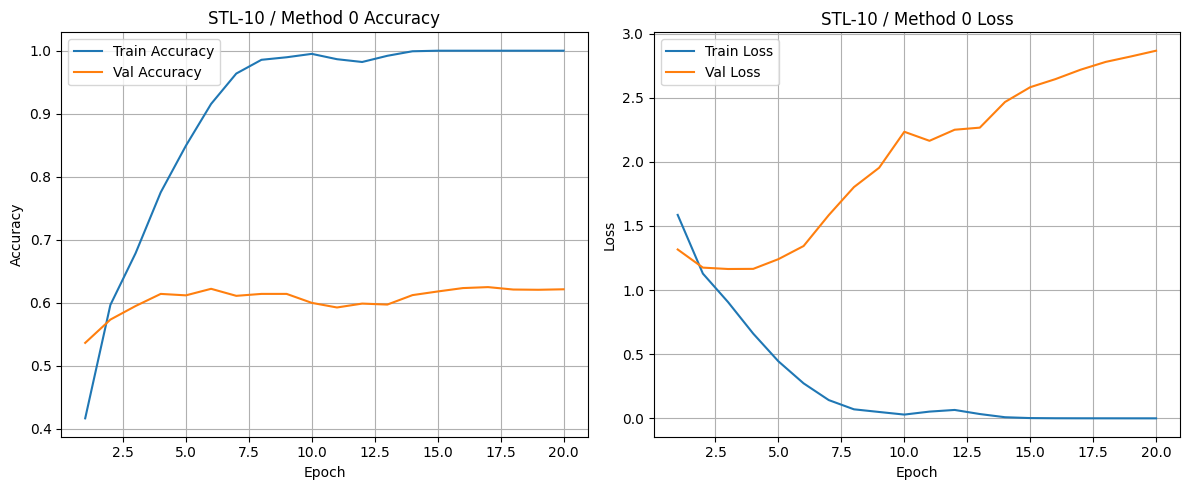



STL-10 - Method 1
------------------
Epoch 1/20
163/163 - 13s - 83ms/step - accuracy: 0.3693 - loss: 1.7048 - val_accuracy: 0.4996 - val_loss: 1.3878
Epoch 2/20
163/163 - 12s - 72ms/step - accuracy: 0.5188 - loss: 1.3225 - val_accuracy: 0.5677 - val_loss: 1.2093
Epoch 3/20
163/163 - 12s - 74ms/step - accuracy: 0.5719 - loss: 1.1959 - val_accuracy: 0.5681 - val_loss: 1.2106
Epoch 4/20
163/163 - 12s - 74ms/step - accuracy: 0.6028 - loss: 1.1089 - val_accuracy: 0.6185 - val_loss: 1.0860
Epoch 5/20
163/163 - 12s - 75ms/step - accuracy: 0.6245 - loss: 1.0504 - val_accuracy: 0.5854 - val_loss: 1.2001
Epoch 6/20
163/163 - 12s - 74ms/step - accuracy: 0.6418 - loss: 1.0002 - val_accuracy: 0.6377 - val_loss: 1.0713
Epoch 7/20
163/163 - 12s - 72ms/step - accuracy: 0.6665 - loss: 0.9382 - val_accuracy: 0.6408 - val_loss: 1.0774
Epoch 8/20
163/163 - 12s - 73ms/step - accuracy: 0.6919 - loss: 0.8794 - val_accuracy: 0.6431 - val_loss: 1.0330
Epoch 9/20
163/163 - 12s - 74ms/step - accuracy: 0.7054 -

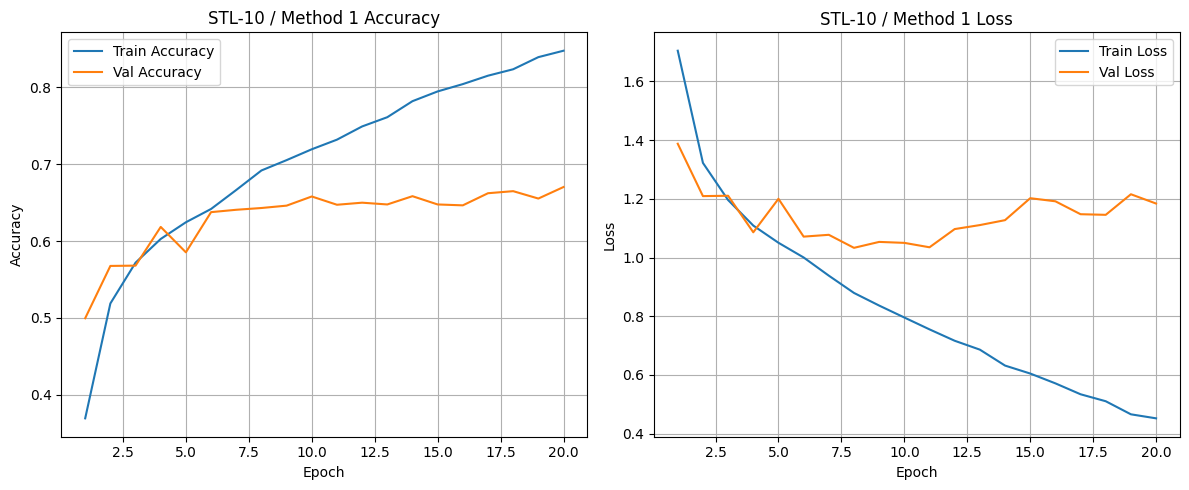



STL-10 - Method 2
------------------
Epoch 1/20
163/163 - 13s - 81ms/step - accuracy: 0.3501 - loss: 1.7667 - val_accuracy: 0.4846 - val_loss: 1.3830
Epoch 2/20
163/163 - 12s - 73ms/step - accuracy: 0.4887 - loss: 1.3898 - val_accuracy: 0.5427 - val_loss: 1.2402
Epoch 3/20
163/163 - 12s - 73ms/step - accuracy: 0.5459 - loss: 1.2662 - val_accuracy: 0.5554 - val_loss: 1.2336
Epoch 4/20
163/163 - 12s - 73ms/step - accuracy: 0.5813 - loss: 1.1648 - val_accuracy: 0.6123 - val_loss: 1.0820
Epoch 5/20
163/163 - 12s - 73ms/step - accuracy: 0.6162 - loss: 1.0843 - val_accuracy: 0.6192 - val_loss: 1.0909
Epoch 6/20
163/163 - 12s - 75ms/step - accuracy: 0.6261 - loss: 1.0310 - val_accuracy: 0.6523 - val_loss: 1.0059
Epoch 7/20
163/163 - 12s - 72ms/step - accuracy: 0.6609 - loss: 0.9588 - val_accuracy: 0.6627 - val_loss: 0.9764
Epoch 8/20
163/163 - 12s - 73ms/step - accuracy: 0.6726 - loss: 0.9171 - val_accuracy: 0.6638 - val_loss: 0.9455
Epoch 9/20
163/163 - 12s - 76ms/step - accuracy: 0.6929 -

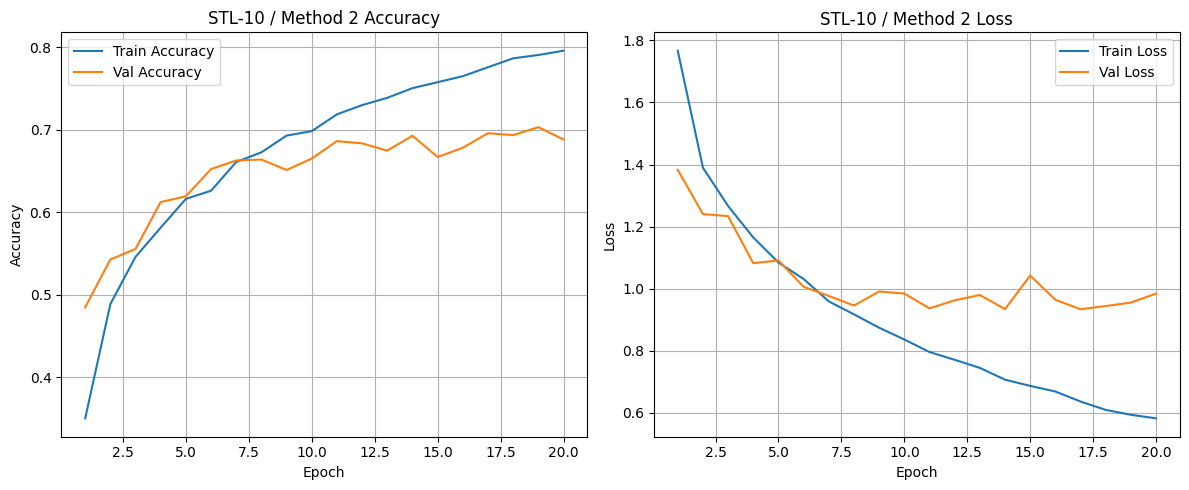



STL-10 - Method 3
------------------
Epoch 1/20
163/163 - 14s - 87ms/step - accuracy: 0.3661 - loss: 1.7233 - val_accuracy: 0.4712 - val_loss: 1.4044
Epoch 2/20
163/163 - 12s - 77ms/step - accuracy: 0.5262 - loss: 1.3101 - val_accuracy: 0.5588 - val_loss: 1.2438
Epoch 3/20
163/163 - 13s - 77ms/step - accuracy: 0.6001 - loss: 1.1170 - val_accuracy: 0.5427 - val_loss: 1.2716
Epoch 4/20
163/163 - 12s - 76ms/step - accuracy: 0.6468 - loss: 0.9927 - val_accuracy: 0.6000 - val_loss: 1.1488
Epoch 5/20
163/163 - 13s - 81ms/step - accuracy: 0.6989 - loss: 0.8490 - val_accuracy: 0.5846 - val_loss: 1.1924
Epoch 6/20
163/163 - 13s - 79ms/step - accuracy: 0.7439 - loss: 0.7353 - val_accuracy: 0.6185 - val_loss: 1.1733
Epoch 7/20
163/163 - 13s - 78ms/step - accuracy: 0.7964 - loss: 0.6025 - val_accuracy: 0.6077 - val_loss: 1.2911
Epoch 8/20
163/163 - 13s - 79ms/step - accuracy: 0.8259 - loss: 0.5029 - val_accuracy: 0.6235 - val_loss: 1.2698
Epoch 9/20
163/163 - 13s - 77ms/step - accuracy: 0.8635 -

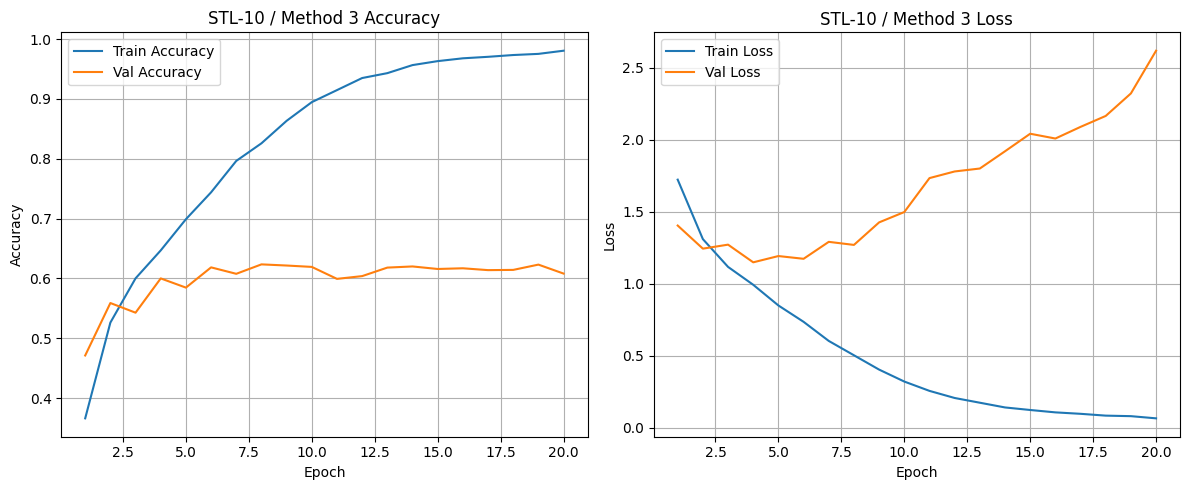



STL-10 - Method 4
------------------
Epoch 1/20
163/163 - 14s - 88ms/step - accuracy: 0.3600 - loss: 1.7362 - val_accuracy: 0.4658 - val_loss: 1.5605
Epoch 2/20
163/163 - 13s - 79ms/step - accuracy: 0.4663 - loss: 1.4412 - val_accuracy: 0.5112 - val_loss: 1.3514
Epoch 3/20
163/163 - 14s - 84ms/step - accuracy: 0.5052 - loss: 1.3455 - val_accuracy: 0.5465 - val_loss: 1.2566
Epoch 4/20
163/163 - 14s - 84ms/step - accuracy: 0.5446 - loss: 1.2710 - val_accuracy: 0.5808 - val_loss: 1.2075
Epoch 5/20
163/163 - 13s - 80ms/step - accuracy: 0.5587 - loss: 1.2076 - val_accuracy: 0.5885 - val_loss: 1.1597
Epoch 6/20
163/163 - 13s - 78ms/step - accuracy: 0.5704 - loss: 1.1677 - val_accuracy: 0.5869 - val_loss: 1.1947
Epoch 7/20
163/163 - 13s - 78ms/step - accuracy: 0.5910 - loss: 1.1271 - val_accuracy: 0.6104 - val_loss: 1.1229
Epoch 8/20
163/163 - 13s - 78ms/step - accuracy: 0.6086 - loss: 1.0864 - val_accuracy: 0.6165 - val_loss: 1.0682
Epoch 9/20
163/163 - 13s - 78ms/step - accuracy: 0.6137 -

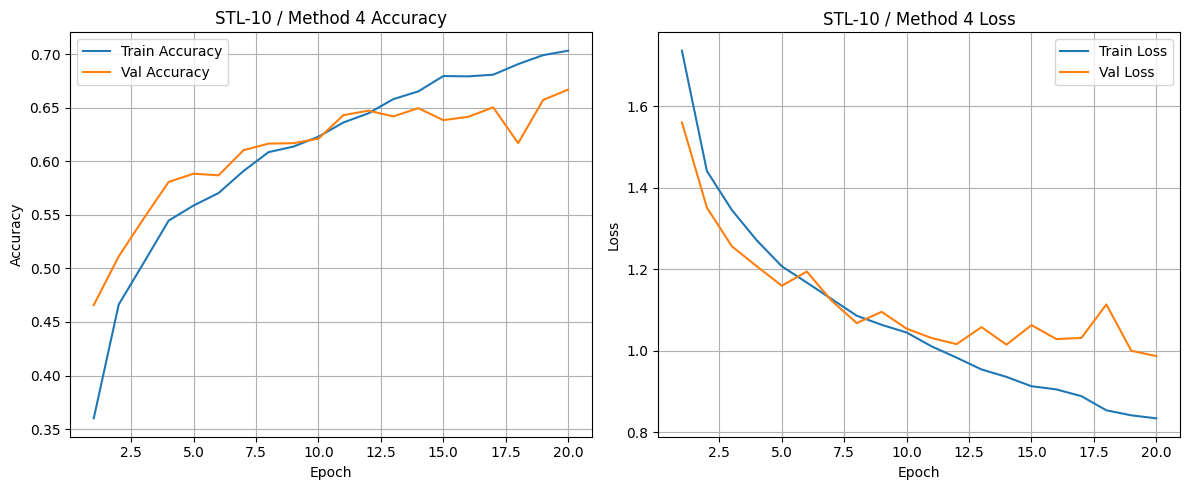



STL-10 - Method 5
------------------
Epoch 1/20
163/163 - 13s - 82ms/step - accuracy: 0.3504 - loss: 1.8290 - val_accuracy: 0.4623 - val_loss: 1.4842
Epoch 2/20
163/163 - 12s - 74ms/step - accuracy: 0.5264 - loss: 1.4662 - val_accuracy: 0.5292 - val_loss: 1.2742
Epoch 3/20
163/163 - 12s - 74ms/step - accuracy: 0.6093 - loss: 1.2776 - val_accuracy: 0.5727 - val_loss: 1.2173
Epoch 4/20
163/163 - 13s - 78ms/step - accuracy: 0.6846 - loss: 1.1213 - val_accuracy: 0.6158 - val_loss: 1.1122
Epoch 5/20
163/163 - 12s - 76ms/step - accuracy: 0.7491 - loss: 0.9732 - val_accuracy: 0.5804 - val_loss: 1.2218
Epoch 6/20
163/163 - 12s - 75ms/step - accuracy: 0.7982 - loss: 0.8670 - val_accuracy: 0.6092 - val_loss: 1.1877
Epoch 7/20
163/163 - 12s - 73ms/step - accuracy: 0.8504 - loss: 0.7429 - val_accuracy: 0.6088 - val_loss: 1.2373
Epoch 8/20
163/163 - 12s - 73ms/step - accuracy: 0.8909 - loss: 0.6659 - val_accuracy: 0.6077 - val_loss: 1.2522
Epoch 9/20
163/163 - 12s - 74ms/step - accuracy: 0.9162 -

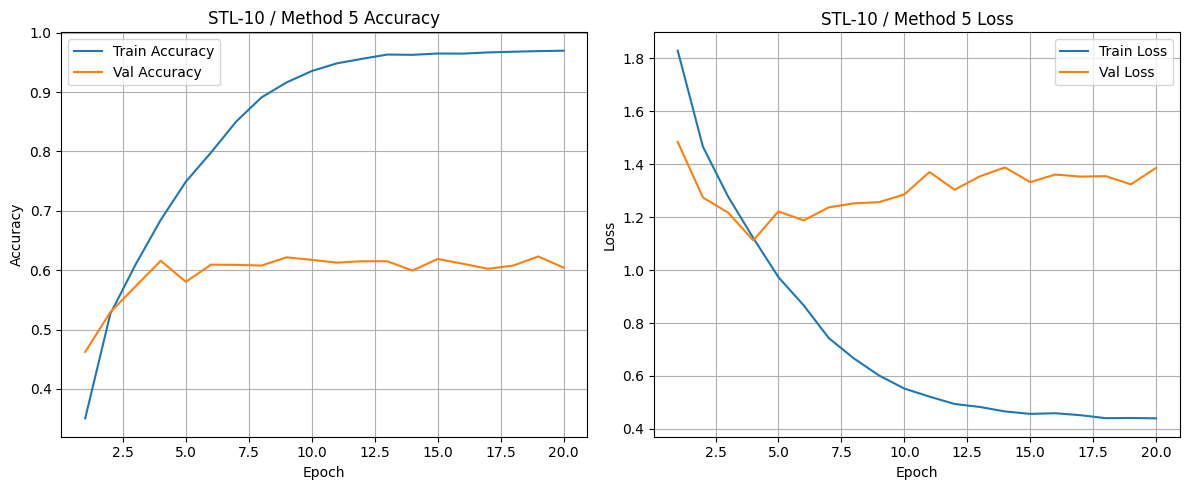



STL-10 - Method 6
------------------
Epoch 1/20
163/163 - 13s - 82ms/step - accuracy: 0.3037 - loss: 1.9893 - val_accuracy: 0.4785 - val_loss: 1.4634
Epoch 2/20
163/163 - 12s - 73ms/step - accuracy: 0.4220 - loss: 1.7784 - val_accuracy: 0.5458 - val_loss: 1.3141
Epoch 3/20
163/163 - 12s - 73ms/step - accuracy: 0.4721 - loss: 1.6856 - val_accuracy: 0.5696 - val_loss: 1.2243
Epoch 4/20
163/163 - 12s - 74ms/step - accuracy: 0.5301 - loss: 1.5801 - val_accuracy: 0.6108 - val_loss: 1.1494
Epoch 5/20
163/163 - 12s - 74ms/step - accuracy: 0.5838 - loss: 1.4946 - val_accuracy: 0.6050 - val_loss: 1.1198
Epoch 6/20
163/163 - 12s - 73ms/step - accuracy: 0.6075 - loss: 1.4315 - val_accuracy: 0.6231 - val_loss: 1.1081
Epoch 7/20
163/163 - 12s - 73ms/step - accuracy: 0.6526 - loss: 1.3551 - val_accuracy: 0.6369 - val_loss: 1.0423
Epoch 8/20
163/163 - 12s - 73ms/step - accuracy: 0.6811 - loss: 1.2926 - val_accuracy: 0.6308 - val_loss: 1.0802
Epoch 9/20
163/163 - 12s - 73ms/step - accuracy: 0.6950 -

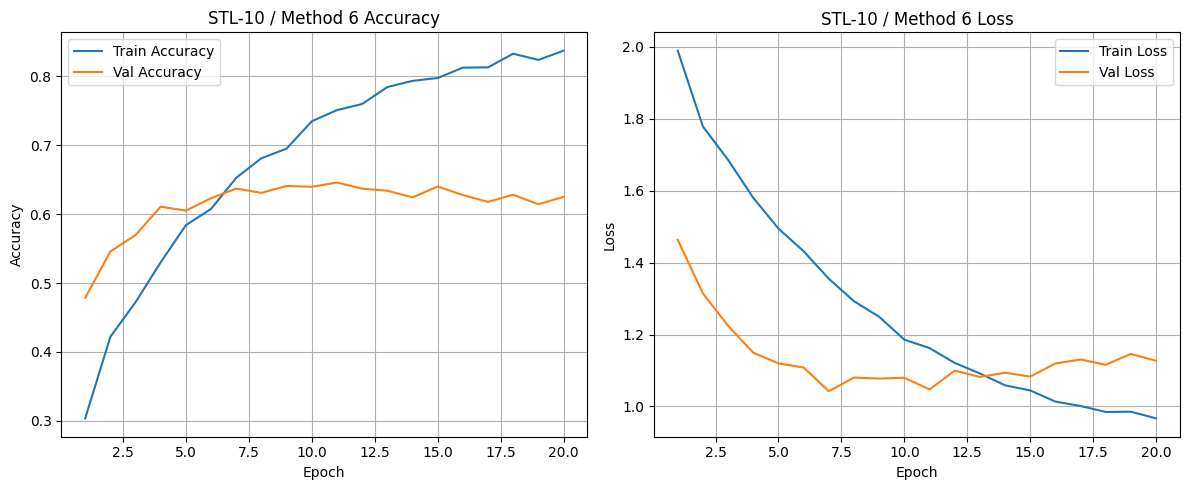



STL-10 - Method 7
------------------
Epoch 1/20
163/163 - 30s - 187ms/step - accuracy: 0.2039 - loss: 2.1532 - val_accuracy: 0.4042 - val_loss: 1.6234
Epoch 2/20
163/163 - 29s - 179ms/step - accuracy: 0.3138 - loss: 1.8603 - val_accuracy: 0.4888 - val_loss: 1.4156
Epoch 3/20
163/163 - 29s - 176ms/step - accuracy: 0.3832 - loss: 1.7002 - val_accuracy: 0.5154 - val_loss: 1.3305
Epoch 4/20
163/163 - 29s - 177ms/step - accuracy: 0.4019 - loss: 1.6527 - val_accuracy: 0.5315 - val_loss: 1.2932
Epoch 5/20
163/163 - 29s - 178ms/step - accuracy: 0.4316 - loss: 1.5594 - val_accuracy: 0.5604 - val_loss: 1.2464
Epoch 6/20
163/163 - 29s - 176ms/step - accuracy: 0.4397 - loss: 1.5766 - val_accuracy: 0.5773 - val_loss: 1.1953
Epoch 7/20
163/163 - 29s - 176ms/step - accuracy: 0.4803 - loss: 1.4742 - val_accuracy: 0.5842 - val_loss: 1.1851
Epoch 8/20
163/163 - 29s - 176ms/step - accuracy: 0.4914 - loss: 1.4386 - val_accuracy: 0.5954 - val_loss: 1.1542
Epoch 9/20
163/163 - 29s - 177ms/step - accuracy:

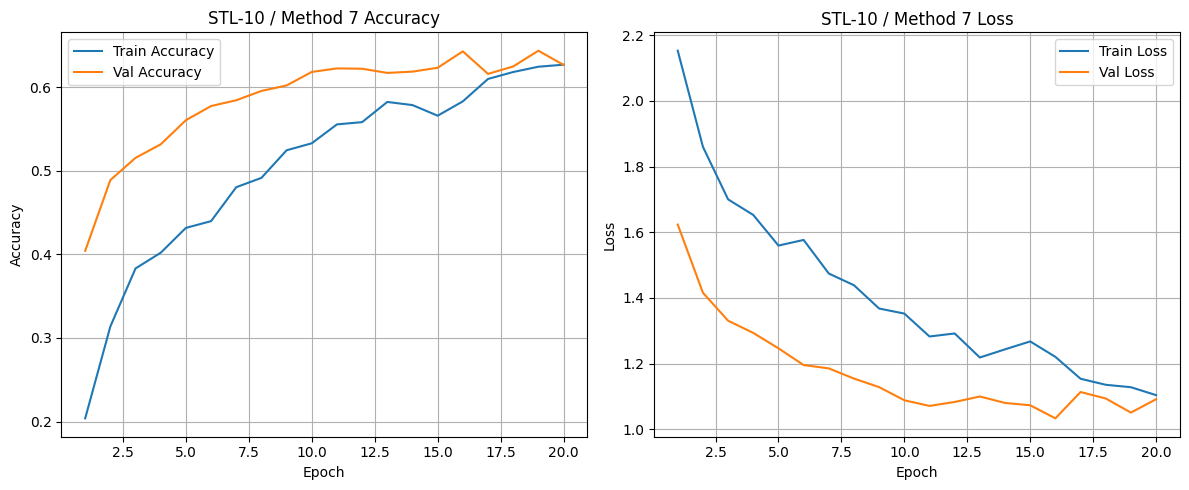


Final accuracy summary (STL-10):
Method 0: train_acc=1.0000, val_acc=0.6215
Method 1: train_acc=0.8478, val_acc=0.6704
Method 2: train_acc=0.7958, val_acc=0.6881
Method 3: train_acc=0.9807, val_acc=0.6081
Method 4: train_acc=0.7033, val_acc=0.6669
Method 5: train_acc=0.9696, val_acc=0.6042
Method 6: train_acc=0.8370, val_acc=0.6250
Method 7: train_acc=0.6267, val_acc=0.6265


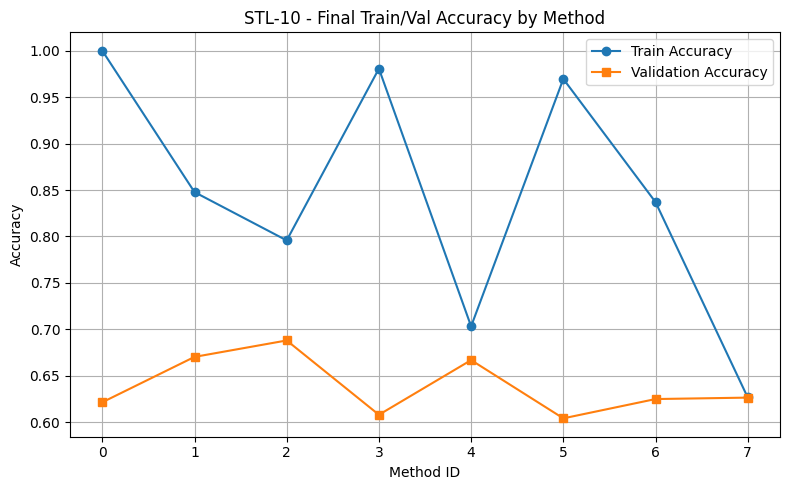

In [3]:
ds = tfds.load("stl10", split="train+test", as_supervised=True)

images = []
labels = []

for img, lab in tfds.as_numpy(ds):
    images.append(img)
    labels.append(lab)

X = np.stack(images).astype("float32") / 255.0
y = np.array(labels).astype("int64")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, shuffle=True
)

input_shape = (96, 96, 3)
num_classes = 10
is_rgb = True

results = {}

for method_id in range(8):
    print("\n")
    print(f"STL-10 - Method {method_id}")
    print("------------------")

    history, train_acc, val_acc = run_method(
        X_train, y_train, X_val, y_val,
        input_shape=input_shape,
        num_classes=num_classes,
        method_id=method_id,
        is_rgb=is_rgb
    )

    results[method_id] = (train_acc, val_acc)
    plot_acc_loss(history, title_prefix=f"STL-10 / Method {method_id}")

print("\nFinal accuracy summary (STL-10):")
for k in range(8):
    ta, va = results[k]
    print(f"Method {k}: train_acc={ta:.4f}, val_acc={va:.4f}")

plot_final_summary(results, title="STL-10 - Final Train/Val Accuracy by Method")